# Governance Effectiveness and Control of Corruption in Global Society: A Data-Driven Analysis (2013–2023)
### (Population and Society)

## Introduction and Project Overview

This project explores the relationship between governance quality and human development from 2013 to 2023 within the Population and Society domain. The central idea is that strong institutions do not always guarantee higher living standards. By combining clustering and forecasting models, the study examines how institutional performance and human development evolve together or diverge over time.

Two methods are applied. Clustering (K-Means and Agglomerative) groups countries by governance and social indicators to detect structural patterns. ARIMA and SARIMA forecast the Human Development Index (HDI) from 2024 to 2033 to evaluate whether institutional improvements translate into long-term progress.

## Problem Definition and Objectives

The main question is whether stronger institutions consistently lead to better human development or if deeper historical and geopolitical forces influence this link. The objectives are to cluster countries by institutional, education, and income variables, compare clustering results using Silhouette and Davies–Bouldin scores, identify mismatches between governance and development, and forecast future HDI trends to understand long-term institutional effects.

## Motivation and Theoretical Rationale

The motivation arises from persistent global inequalities. Thinkers like Halford Mackinder, Raúl Prebisch, and Jason Hickel show that governance and development are shaped by power, history, and dependency, not only by institutional efficiency. Institutional quality is treated here as a dynamic, historically conditioned system. Understanding where governance and human development diverge helps explain why some societies achieve sustainable progress while others remain structurally constrained.

## Data Sources

World Governance Indicators (World Bank)
URL: [https://databank.worldbank.org/source/worldwide-governance-indicators](https://databank.worldbank.org/source/worldwide-governance-indicators)
License: CC BY 4.0

Human Development Reports (UNDP)
URL: [https://hdr.undp.org/data-center/documentation-and-downloads](https://hdr.undp.org/data-center/documentation-and-downloads)
License: CC BY 3.0 IGO

Variables include control_of_corruption, government_effectiveness, rule_of_law, hdi, education_index, life_expectancy, and gni_per_capita.

## Dataset Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1= pd.read_csv("WGI_Data_2013_2023.csv")

In [3]:
df1.head()

,Country Name,Country Code,Series Name,Series Code,2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Afghanistan,AFG,Control of Corruption: Estimate,CC.EST,-1.44596064090729,-1.36493408679962,-1.35471308231354,-1.54022777080536,-1.53007459640503,-1.50287592411041,-1.41931009292603,-1.49336087703705,-1.15226578712463,-1.18368434906006,-1.15493178367615
1,Afghanistan,AFG,Control of Corruption: Number of Sources,CC.NO.SRC,11,11,11,10,10,10,10,9,8,8,8
2,Afghanistan,AFG,Control of Corruption: Percentile Rank,CC.PER.RNK,0.947867274284363,5.28846168518066,5.7142858505249,3.80952382087708,3.80952382087708,4.7619047164917,5.7142858505249,4.7619047164917,12.380952835083,12.2641506195068,13.6792449951172
3,Afghanistan,AFG,"Control of Corruption: Percentile Rank, Lower ...",CC.PER.RNK.LOWER,0,0,0.476190477609634,0,0,0,1.42857146263123,0,4.7619047164917,4.71698093414307,6.13207530975342
4,Afghanistan,AFG,"Control of Corruption: Percentile Rank, Upper ...",CC.PER.RNK.UPPER,9.95260620117188,12.5,12.8571424484253,10,9.5238094329834,9.5238094329834,11.9047622680664,10.4761905670166,20.9523811340332,20.2830181121826,20.7547168731689


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7709 entries, 0 to 7708
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   7706 non-null   object
 1   Country Code   7704 non-null   object
 2   Series Name    7704 non-null   object
 3   Series Code    7704 non-null   object
 4   2013 [YR2013]  7704 non-null   object
 5   2014 [YR2014]  7704 non-null   object
 6   2015 [YR2015]  7704 non-null   object
 7   2016 [YR2016]  7704 non-null   object
 8   2017 [YR2017]  7704 non-null   object
 9   2018 [YR2018]  7704 non-null   object
 10  2019 [YR2019]  7704 non-null   object
 11  2020 [YR2020]  7704 non-null   object
 12  2021 [YR2021]  7704 non-null   object
 13  2022 [YR2022]  7704 non-null   object
 14  2023 [YR2023]  7704 non-null   object
dtypes: object(15)
memory usage: 903.5+ KB


In [5]:
df1.shape

(7709, 15)

In [6]:
df1.describe()

,Country Name,Country Code,Series Name,Series Code,2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
count,7706,7704,7704,7704,7704,7704,7704,7704,7704,7704,7704,7704,7704,7704,7704
unique,216,214,36,36,2279,2410,2221,2212,2231,2444,2449,2394,2348,2164,2418
top,Afghanistan,AFG,Control of Corruption: Estimate,CC.EST,9,..,9,9,8,8,8,7,7,7,8
freq,36,36,214,214,141,198,159,165,167,168,170,166,178,182,161


In [7]:
df1.columns.tolist()

['Country Name',
 'Country Code',
 'Series Name',
 'Series Code',
 '2013 [YR2013]',
 '2014 [YR2014]',
 '2015 [YR2015]',
 '2016 [YR2016]',
 '2017 [YR2017]',
 '2018 [YR2018]',
 '2019 [YR2019]',
 '2020 [YR2020]',
 '2021 [YR2021]',
 '2022 [YR2022]',
 '2023 [YR2023]']

In [8]:
df2 = pd.read_csv("HDR_2013_2023.csv")

In [9]:
df2.head()

,countryIsoCode,country,indexCode,index,dimension,indicatorCode,indicator,year,value,note
0,AFG,Afghanistan,GII,Gender Inequality Index,NaN,abr,"Adolescent Birth Rate (births per 1,000 women ...",2013,89.337,NaN
1,AFG,Afghanistan,GII,Gender Inequality Index,NaN,abr,"Adolescent Birth Rate (births per 1,000 women ...",2014,84.069,NaN
2,AFG,Afghanistan,GII,Gender Inequality Index,NaN,abr,"Adolescent Birth Rate (births per 1,000 women ...",2015,81.043,NaN
3,AFG,Afghanistan,GII,Gender Inequality Index,NaN,abr,"Adolescent Birth Rate (births per 1,000 women ...",2016,78.130,NaN
4,AFG,Afghanistan,GII,Gender Inequality Index,NaN,abr,"Adolescent Birth Rate (births per 1,000 women ...",2017,75.300,NaN


In [10]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74410 entries, 0 to 74409
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   countryIsoCode  74410 non-null  object 
 1   country         74410 non-null  object 
 2   indexCode       74410 non-null  object 
 3   index           74410 non-null  object 
 4   dimension       1090 non-null   object 
 5   indicatorCode   74410 non-null  object 
 6   indicator       74410 non-null  object 
 7   year            74410 non-null  int64  
 8   value           74387 non-null  float64
 9   note            1199 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 5.7+ MB


In [11]:
df2.info

<bound method DataFrame.info of       countryIsoCode      country indexCode                    index  \
0                AFG  Afghanistan       GII  Gender Inequality Index   
1                AFG  Afghanistan       GII  Gender Inequality Index   
2                AFG  Afghanistan       GII  Gender Inequality Index   
3                AFG  Afghanistan       GII  Gender Inequality Index   
4                AFG  Afghanistan       GII  Gender Inequality Index   
...              ...          ...       ...                      ...   
74405      ZZK.WORLD        World       GII  Gender Inequality Index   
74406      ZZK.WORLD        World       GII  Gender Inequality Index   
74407      ZZK.WORLD        World       GII  Gender Inequality Index   
74408      ZZK.WORLD        World       GII  Gender Inequality Index   
74409      ZZK.WORLD        World       GII  Gender Inequality Index   

      dimension indicatorCode  \
0           NaN           abr   
1           NaN           abr   
2   

In [12]:
df2.describe

<bound method NDFrame.describe of       countryIsoCode      country indexCode                    index  \
0                AFG  Afghanistan       GII  Gender Inequality Index   
1                AFG  Afghanistan       GII  Gender Inequality Index   
2                AFG  Afghanistan       GII  Gender Inequality Index   
3                AFG  Afghanistan       GII  Gender Inequality Index   
4                AFG  Afghanistan       GII  Gender Inequality Index   
...              ...          ...       ...                      ...   
74405      ZZK.WORLD        World       GII  Gender Inequality Index   
74406      ZZK.WORLD        World       GII  Gender Inequality Index   
74407      ZZK.WORLD        World       GII  Gender Inequality Index   
74408      ZZK.WORLD        World       GII  Gender Inequality Index   
74409      ZZK.WORLD        World       GII  Gender Inequality Index   

      dimension indicatorCode  \
0           NaN           abr   
1           NaN           abr   
2 

In [13]:
df2.columns

Index(['countryIsoCode', 'country', 'indexCode', 'index', 'dimension',
       'indicatorCode', 'indicator', 'year', 'value', 'note'],
      dtype='object')

## Data Cleaning and Transformation (Melting / Pivoting)

In [14]:
print(df1.columns.tolist())

['Country Name', 'Country Code', 'Series Name', 'Series Code', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]']


In [15]:
df1.columns = df1.columns.str.replace(r"\s*\[YR\d+\]", "", regex=True)
selected_series = ["Control of Corruption: Estimate","Government Effectiveness: Estimate","Regulatory Quality: Estimate","Rule of Law: Estimate"]

df1_filtered = df1[df1["Series Name"].isin(selected_series)]
df1_melt = df1_filtered.melt(id_vars=["Country Name", "Series Name"], var_name="Year",value_name="Value")
df1_melt["Year"] = pd.to_numeric(df1_melt["Year"], errors="coerce")
df1_melt["Value"] = pd.to_numeric(df1_melt["Value"], errors="coerce")


df1_clean = df1_melt.pivot_table(index=["Country Name", "Year"], columns="Series Name", values="Value").reset_index()

print("WGI clean:", df1_clean.shape)
df1_clean.head(10)

WGI clean: (2326, 6)


Series Name,Country Name,Year,Control of Corruption: Estimate,Government Effectiveness: Estimate,Regulatory Quality: Estimate,Rule of Law: Estimate
0,Afghanistan,2013.0,-1.445961,-1.401463,-1.193090,-1.609755
1,Afghanistan,2014.0,-1.364934,-1.361646,-1.124134,-1.437702
2,Afghanistan,2015.0,-1.354713,-1.397395,-1.018826,-1.516201
3,Afghanistan,2016.0,-1.540228,-1.291468,-1.339695,-1.522534
4,Afghanistan,2017.0,-1.530075,-1.386597,-1.363010,-1.581176
5,Afghanistan,2018.0,-1.502876,-1.501758,-1.138204,-1.689124
6,Afghanistan,2019.0,-1.419310,-1.519113,-1.113778,-1.742100
7,Afghanistan,2020.0,-1.493361,-1.611539,-1.389163,-1.831407
8,Afghanistan,2021.0,-1.152266,-1.670588,-1.311682,-1.877234
9,Afghanistan,2022.0,-1.183684,-1.880035,-1.271806,-1.659846


In [16]:
print("Unique quantity:", df2["indicator"].nunique())
print(df2["indicator"].unique()[:50]) 

Unique quantity: 51
['Adolescent Birth Rate (births per 1,000 women ages 15-19)' 'Assets (%)'
 'Child mortality (%)'
 'Carbon dioxide emissions per capita (production) (tonnes)'
 'Coefficient of human inequality' 'Cooking fuel (%)'
 'Difference from HDI value (%)' 'Drinking water (%)' 'Electricity (%)'
 'Expected Years of Schooling (years)'
 'Expected Years of Schooling, female (years)'
 'Expected Years of Schooling, male (years)'
 'Gender Development Index (value)' 'GDI Group'
 'Gender Inequality Index (value)' 'GII Rank'
 'Gross National Income Per Capita, female (2021 PPP$)'
 'Gross National Income Per Capita, male (2021 PPP$)'
 'Gross National Income Per Capita (2021 PPP$)'
 'Human Development Index (value)' 'HDI female' 'HDI male' 'HDI Rank'
 'Housing (%)' 'Inequality-adjusted Human Development Index (value)'
 'Inequality in eduation' 'Inequality in income'
 'Inequality in life expectancy' 'Life Expectancy at Birth (years)'
 'Life Expectancy at Birth, female (years)'
 'Life Expect

In [17]:
# PIVOT HDR 
df2_sub = df2[["country", "year", "indicator", "value"]].copy()
df2_sub["year"]  = pd.to_numeric(df2_sub["year"], errors="coerce")
df2_sub["value"] = pd.to_numeric(df2_sub["value"], errors="coerce")
df2_sub = df2_sub[df2_sub["year"].between(2013, 2023, inclusive="both")]

df2_pivot = df2_sub.pivot_table(index=["country", "year"],columns="indicator",values="value",aggfunc="mean").reset_index()

selected_indicators = [
    "Human Development Index (value)",
    "Gender Inequality Index (value)",
    "Expected Years of Schooling (years)",
    "Mean Years of Schooling (years)",
    "Gross National Income Per Capita (2021 PPP$)",
    "Life Expectancy at Birth (years)",
    "Population with at least some secondary education, female (% ages 25 and older)",
    "Population with at least some secondary education, male (% ages 25 and older)",
    "Labour force participation rate, female (% ages 15 and older)",
    "Labour force participation rate, male (% ages 15 and older)"]

df2_pivot = df2_pivot[[c for c in df2_pivot.columns if c in ["country", "year"] + selected_indicators]]
merged = pd.merge(df1_clean, df2_pivot,left_on=["Country Name", "Year"],right_on=["country", "year"],how="inner")
wgi_cols = ["Control of Corruption: Estimate","Government Effectiveness: Estimate","Regulatory Quality: Estimate","Rule of Law: Estimate"]
final_order = (
    ["Country Name", "Year"]+ [col for col in wgi_cols if col in merged.columns]
    + [col for col in selected_indicators if col in merged.columns])

df = merged.drop(columns=[c for c in ["country", "year"] if c in merged.columns])
df = df.loc[:, final_order].sort_values(["Country Name", "Year"]).reset_index(drop=True)
df.head(10)

,Country Name,Year,Control of Corruption: Estimate,Government Effectiveness: Estimate,Regulatory Quality: Estimate,Rule of Law: Estimate,Human Development Index (value),Gender Inequality Index (value),Expected Years of Schooling (years),Mean Years of Schooling (years),Gross National Income Per Capita (2021 PPP$),Life Expectancy at Birth (years),"Population with at least some secondary education, female (% ages 25 and older)","Population with at least some secondary education, male (% ages 25 and older)","Labour force participation rate, female (% ages 15 and older)","Labour force participation rate, male (% ages 15 and older)"
0,Afghanistan,2013.0,-1.445961,-1.401463,-1.193090,-1.609755,0.492,0.708,10.134183,2.030677,3245.787894,62.188,3.156962,17.807337,20.90,77.06
1,Afghanistan,2014.0,-1.364934,-1.361646,-1.124134,-1.437702,0.497,0.687,10.464680,2.077493,3214.323950,62.260,3.441748,18.542849,25.78,77.08
2,Afghanistan,2015.0,-1.354713,-1.397395,-1.018826,-1.516201,0.496,0.683,10.482975,2.124310,3087.800291,62.270,4.575420,21.342409,24.25,75.77
3,Afghanistan,2016.0,-1.540228,-1.291468,-1.339695,-1.522534,0.495,0.682,10.501270,2.268592,2818.611013,62.646,5.229826,23.629828,22.71,74.47
4,Afghanistan,2017.0,-1.530075,-1.386597,-1.363010,-1.581176,0.496,0.679,10.519565,2.412873,2783.873555,62.406,5.884233,25.917246,21.17,73.16
5,Afghanistan,2018.0,-1.502876,-1.501758,-1.138204,-1.689124,0.498,0.677,10.537860,2.557155,2758.820419,62.443,6.369394,25.953569,19.61,71.06
6,Afghanistan,2019.0,-1.419310,-1.519113,-1.113778,-1.742100,0.507,0.676,10.621292,2.701437,2969.987690,62.941,6.854554,25.989892,18.05,68.95
7,Afghanistan,2020.0,-1.493361,-1.611539,-1.389163,-1.831407,0.501,0.674,10.705385,2.845718,2797.703558,61.454,7.339715,26.026215,16.50,66.84
8,Afghanistan,2021.0,-1.152266,-1.670588,-1.311682,-1.877234,0.486,0.642,10.790143,2.990000,2151.783518,60.417,6.400000,14.870000,23.30,76.96
9,Afghanistan,2022.0,-1.183684,-1.880035,-1.271806,-1.659846,0.495,0.665,10.790143,2.514790,1960.945925,65.617,7.042050,24.077040,23.45,88.62


# Exploratory Data Analysis 

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1868 entries, 0 to 1867
Data columns (total 16 columns):
 #   Column                                                                           Non-Null Count  Dtype  
---  ------                                                                           --------------  -----  
 0   Country Name                                                                     1868 non-null   object 
 1   Year                                                                             1868 non-null   float64
 2   Control of Corruption: Estimate                                                  1866 non-null   float64
 3   Government Effectiveness: Estimate                                               1866 non-null   float64
 4   Regulatory Quality: Estimate                                                     1866 non-null   float64
 5   Rule of Law: Estimate                                                            1868 non-null   float64
 6   Human De

In [19]:
df.describe()

,Year,Control of Corruption: Estimate,Government Effectiveness: Estimate,Regulatory Quality: Estimate,Rule of Law: Estimate,Human Development Index (value),Gender Inequality Index (value),Expected Years of Schooling (years),Mean Years of Schooling (years),Gross National Income Per Capita (2021 PPP$),Life Expectancy at Birth (years),"Population with at least some secondary education, female (% ages 25 and older)","Population with at least some secondary education, male (% ages 25 and older)","Labour force participation rate, female (% ages 15 and older)","Labour force participation rate, male (% ages 15 and older)"
count,1868.000000,1866.000000,1866.000000,1866.000000,1868.000000,1848.000000,1611.000000,1859.000000,1849.000000,1858.000000,1868.000000,1726.000000,1726.000000,1754.000000,1754.000000
mean,2018.004283,-0.022788,-0.021776,-0.022698,-0.020873,0.730445,0.337919,13.487877,8.866497,23975.364703,72.063898,60.005433,64.572455,50.853518,70.523786
std,3.162105,1.008726,1.002515,0.981437,0.992214,0.154423,0.196966,3.085694,3.256163,25459.823703,8.170565,30.305704,26.876226,14.329016,9.772470
min,2013.000000,-1.969555,-2.440229,-2.369393,-2.406621,0.279000,0.003000,5.216297,1.245714,688.347277,18.818000,3.156962,7.660000,10.660000,24.830000
25%,2015.000000,-0.783011,-0.754282,-0.748027,-0.767895,0.610000,0.157500,11.408085,6.198000,5414.054379,66.202750,31.629559,42.328165,43.805000,64.880000
50%,2018.000000,-0.245518,-0.105103,-0.128629,-0.159389,0.755000,0.350000,13.477410,9.435172,14588.764225,73.038000,63.221718,65.598049,52.895000,70.690000
75%,2021.000000,0.646933,0.657310,0.644025,0.651057,0.854000,0.501500,15.584420,11.420000,35123.796495,78.182500,88.817085,90.956888,59.180000,76.807500
max,2023.000000,2.402638,2.317472,2.308591,2.124762,0.972000,0.840000,23.247681,14.296372,175851.486300,86.372000,100.000000,100.000000,88.740000,99.810000


In [20]:
# rename the columns to make easier it process
df = df.rename(columns={
    'Country Name': 'country',
    'Year': 'year',
    'Control of Corruption: Estimate': 'corruption',
    'Government Effectiveness: Estimate': 'gov_effectiveness',
    'Regulatory Quality: Estimate': 'regulatory_quality',
    'Rule of Law: Estimate': 'rule_of_law',
    'Human Development Index (value)': 'hdi',
    'Gender Inequality Index (value)': 'gender_inequality',
    'Expected Years of Schooling (years)': 'expected_school',
    'Mean Years of Schooling (years)': 'mean_school',
    'Gross National Income Per Capita (2021 PPP$)': 'gni_per_capita',
    'Life Expectancy at Birth (years)': 'life_expectancy',
    'Population with at least some secondary education, female (% ages 25 and older)': 'edu_female',
    'Population with at least some secondary education, male (% ages 25 and older)': 'edu_male',
    'Labour force participation rate, female (% ages 15 and older)': 'labour_female',
    'Labour force participation rate, male (% ages 15 and older)': 'labour_male',
    'Cluster': 'cluster'})

# Convert "year" to int
df['year'] = df['year'].astype(int)
threshold = 0.7 
df = df.loc[:, df.isnull().mean() < (1 - threshold)]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1868 entries, 0 to 1867
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             1868 non-null   object 
 1   year                1868 non-null   int32  
 2   corruption          1866 non-null   float64
 3   gov_effectiveness   1866 non-null   float64
 4   regulatory_quality  1866 non-null   float64
 5   rule_of_law         1868 non-null   float64
 6   hdi                 1848 non-null   float64
 7   gender_inequality   1611 non-null   float64
 8   expected_school     1859 non-null   float64
 9   mean_school         1849 non-null   float64
 10  gni_per_capita      1858 non-null   float64
 11  life_expectancy     1868 non-null   float64
 12  edu_female          1726 non-null   float64
 13  edu_male            1726 non-null   float64
 14  labour_female       1754 non-null   float64
 15  labour_male         1754 non-null   float64
dtypes: flo

In [21]:
df.isnull().sum().sort_values(ascending=False)
df.duplicated().sum()
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
year,1868.0,2018.004283,3.162105,2013.000000,2015.000000,2018.000000,2021.000000,2023.000000
corruption,1866.0,-0.022788,1.008726,-1.969555,-0.783011,-0.245518,0.646933,2.402638
gov_effectiveness,1866.0,-0.021776,1.002515,-2.440229,-0.754282,-0.105103,0.657310,2.317472
regulatory_quality,1866.0,-0.022698,0.981437,-2.369393,-0.748027,-0.128629,0.644025,2.308591
rule_of_law,1868.0,-0.020873,0.992214,-2.406621,-0.767895,-0.159389,0.651057,2.124762
hdi,1848.0,0.730445,0.154423,0.279000,0.610000,0.755000,0.854000,0.972000
gender_inequality,1611.0,0.337919,0.196966,0.003000,0.157500,0.350000,0.501500,0.840000
expected_school,1859.0,13.487877,3.085694,5.216297,11.408085,13.477410,15.584420,23.247681
mean_school,1849.0,8.866497,3.256163,1.245714,6.198000,9.435172,11.420000,14.296372
gni_per_capita,1858.0,23975.364703,25459.823703,688.347277,5414.054379,14588.764225,35123.796495,175851.486300


In [22]:
df.fillna(df.groupby('country').transform('mean'), inplace=True)

In [23]:
df[df['life_expectancy'] < 30]
#A data quality inspection identified an unrealistic life expectancy value (18.8 years) for the Central African Republic in 2022.
#To ensure analytical validity, this outlier was corrected by imputing the country’s average life expectancy from previous years, as no human population at national scale can exhibit such a low figure in modern datasets

,country,year,corruption,gov_effectiveness,regulatory_quality,rule_of_law,hdi,gender_inequality,expected_school,mean_school,gni_per_capita,life_expectancy,edu_female,edu_male,labour_female,labour_male
339,Central African Republic,2022,-1.246147,-1.710303,-1.474184,-1.699912,0.3596,NaN,7.435768,3.989431,1095.842755,18.818,14.58,31.98,NaN,NaN


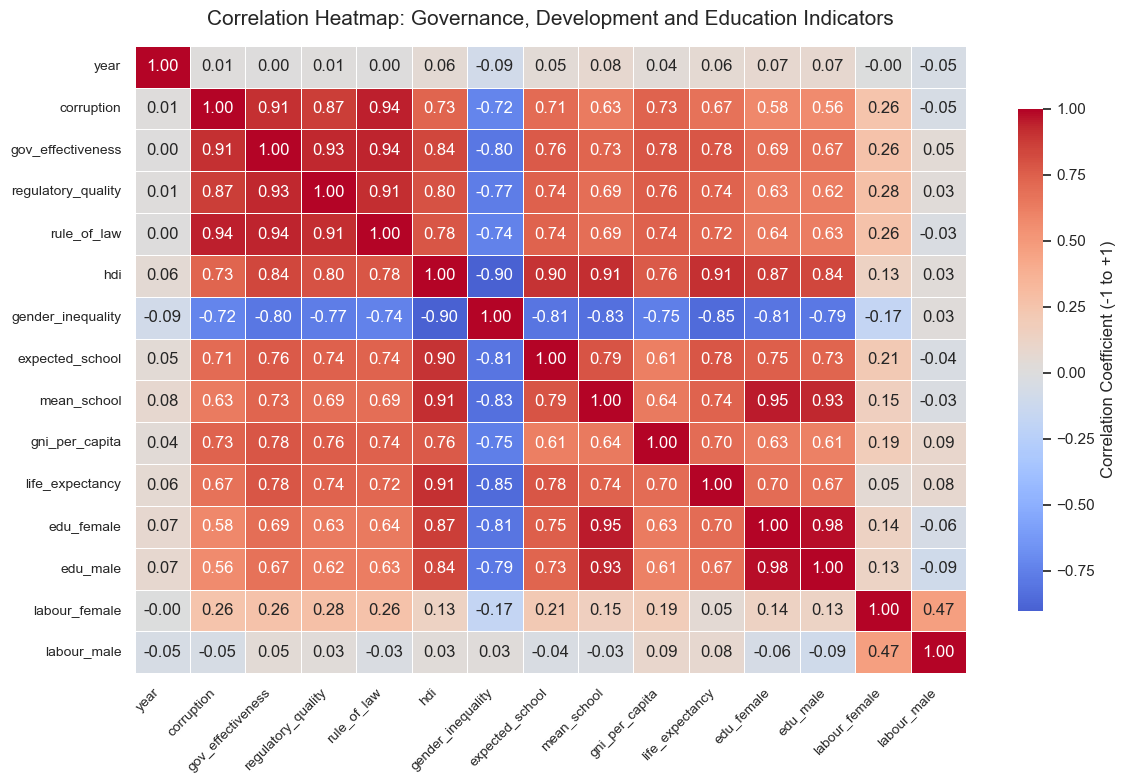

In [24]:
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])
corr = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")
heatmap = sns.heatmap(
    corr,cmap='coolwarm',center=0, annot=True, fmt=".2f", linewidths=0.5, cbar_kws={'shrink': 0.8,'label': 'Correlation Coefficient (-1 to +1)'})
plt.title("Correlation Heatmap: Governance, Development and Education Indicators", fontsize=15, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

plt.show()

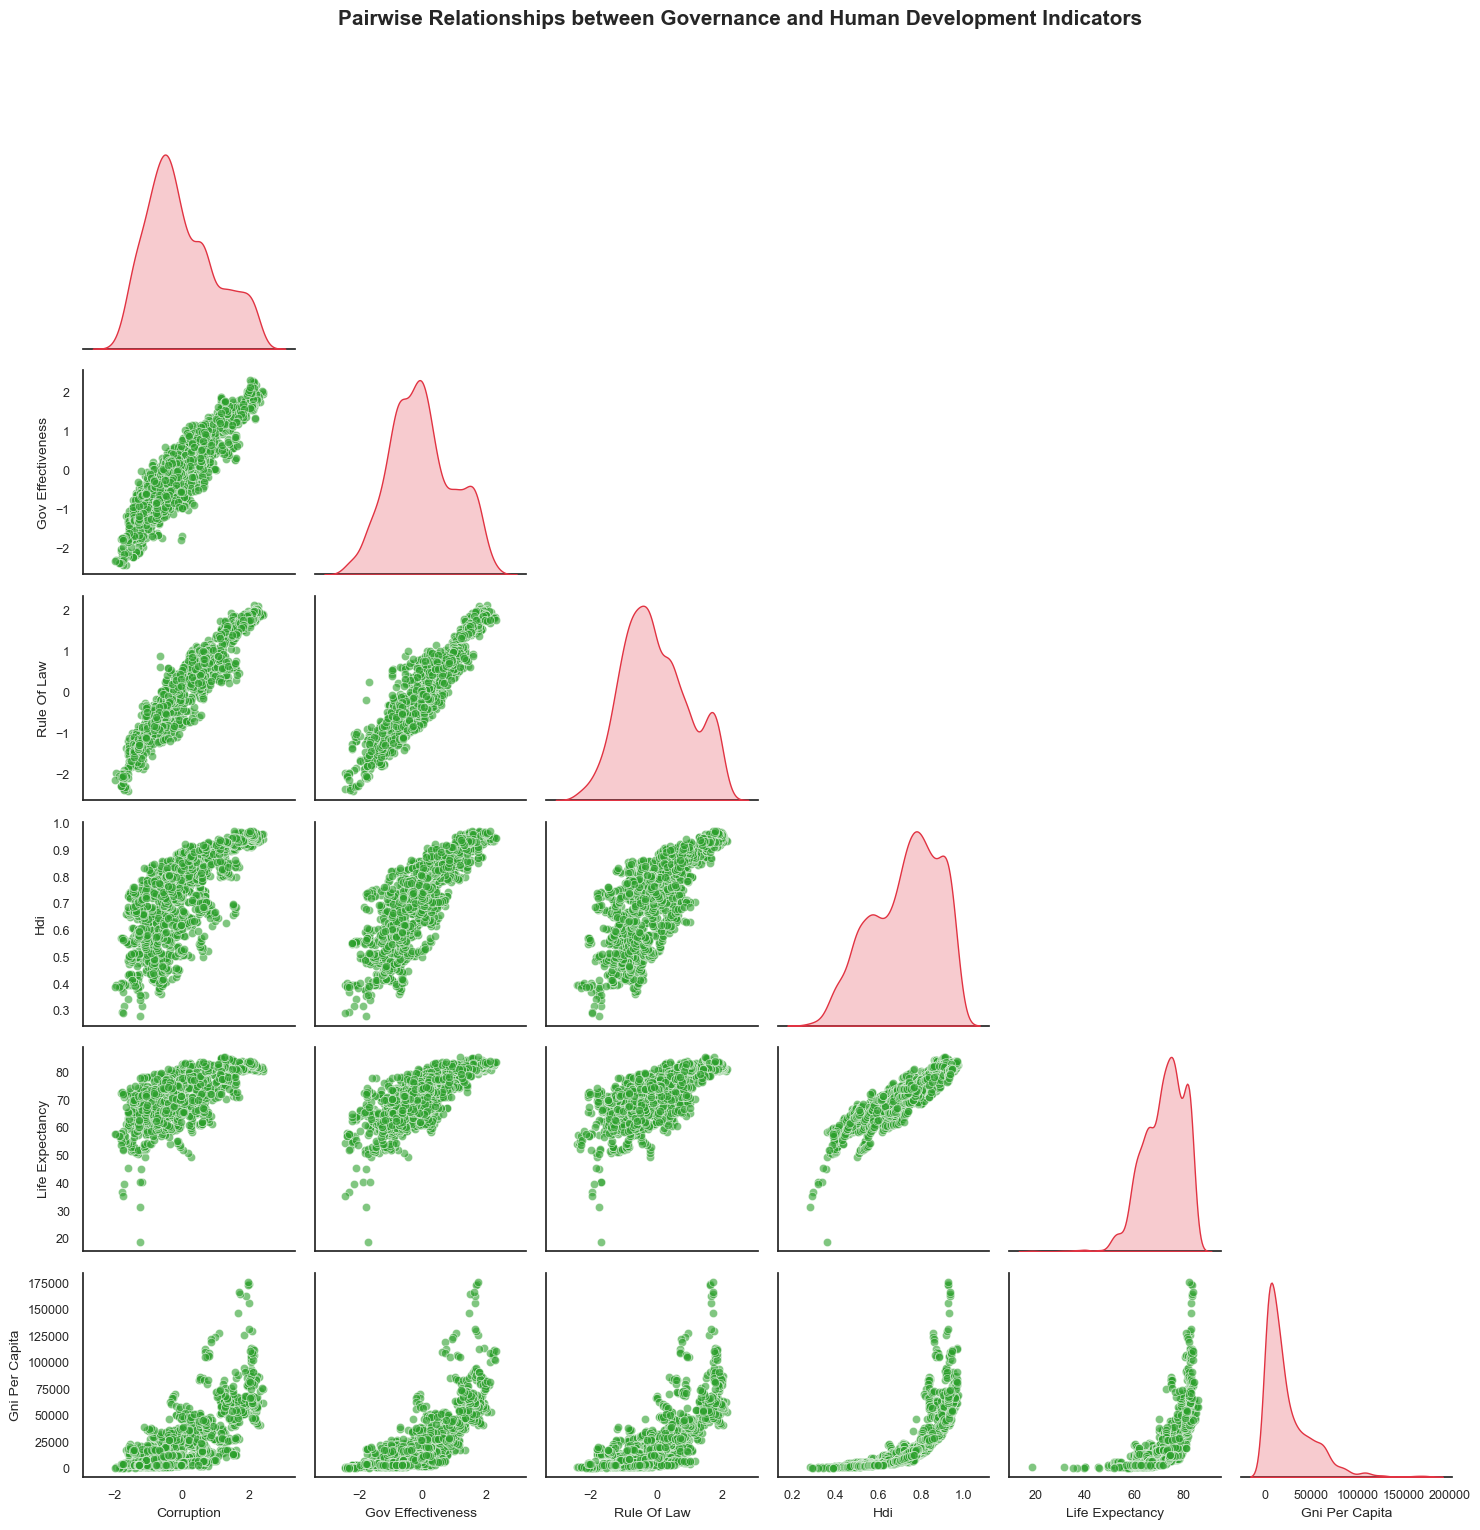

In [25]:
selected_features = ['corruption', 'gov_effectiveness', 'rule_of_law','hdi', 'life_expectancy', 'gni_per_capita']
pairplot_df = numeric_df[selected_features].dropna()
sns.set_theme(style="white", font_scale=1.1)
custom_palette = sns.color_palette("rocket_r", as_cmap=True) 
pairgrid = sns.pairplot(data=pairplot_df, diag_kind='kde', corner=True, plot_kws={'alpha': 0.6, 's': 35,'color': sns.color_palette("tab10")[2]},
    diag_kws={'fill': True, 'color': sns.color_palette("rocket")[3]},)
pairgrid.fig.suptitle("Pairwise Relationships between Governance and Human Development Indicators", fontsize=15, y=1.02, weight='bold')

for ax in pairgrid.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel().replace('_', ' ').title(), fontsize=10)
        ax.set_ylabel(ax.get_ylabel().replace('_', ' ').title(), fontsize=10)
        ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

In [26]:
!pip install pycountry_convert
import pycountry_convert as pc
def country_to_continent(country_name):
    try:
        country_code = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except:
        return None
df['continent'] = df['country'].apply(country_to_continent)
custom_map = {
    'Congo, Dem. Rep.': 'Africa',
    'Congo, Rep.': 'Africa',
    'Venezuela, RB': 'Latin America',
    'Iran, Islamic Rep.': 'Asia'}
df['continent'] = df.apply(
    lambda x: custom_map[x['country']] if x['country'] in custom_map else x['continent'], axis=1)
df = df.dropna(subset=['continent'])

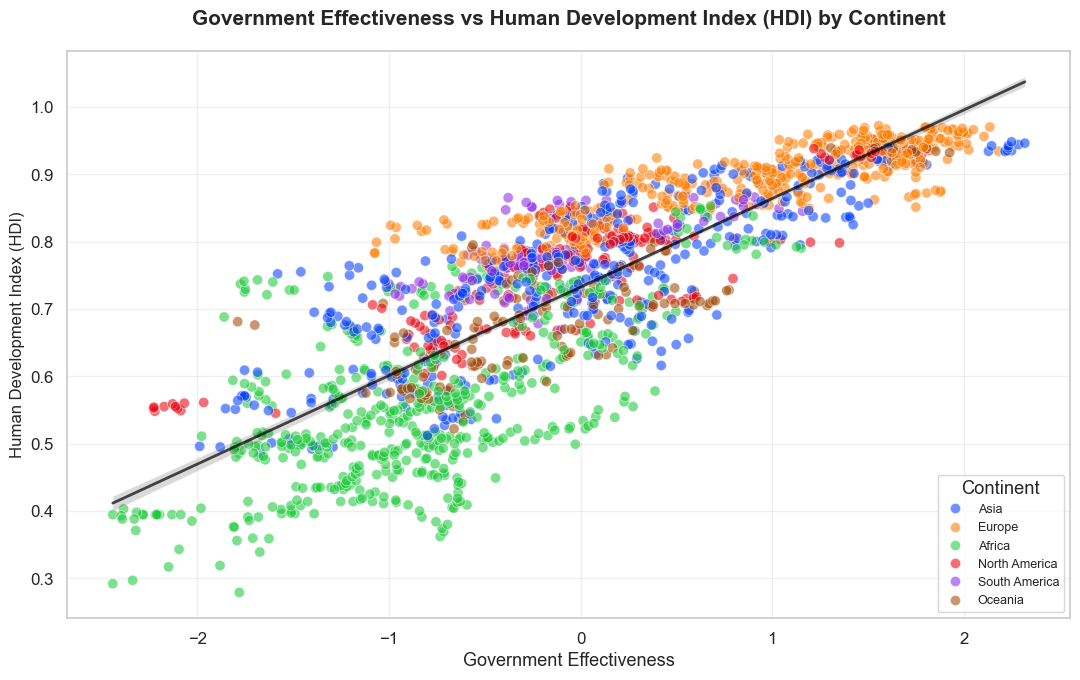

In [27]:
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(11,7))
sns.scatterplot(data=df, x='gov_effectiveness', y='hdi', hue='continent', palette='bright', alpha=0.57, s=55, edgecolor='white')
sns.regplot(data=df, x='gov_effectiveness', y='hdi', scatter=False, color='black', line_kws={'linewidth': 2, 'alpha': 0.7})

plt.title("Government Effectiveness vs Human Development Index (HDI) by Continent", fontsize=15, weight='bold', pad=19)
plt.xlabel("Government Effectiveness", fontsize=13)
plt.ylabel("Human Development Index (HDI)", fontsize=12)
plt.legend(title="Continent", loc='lower right', fontsize=9, frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

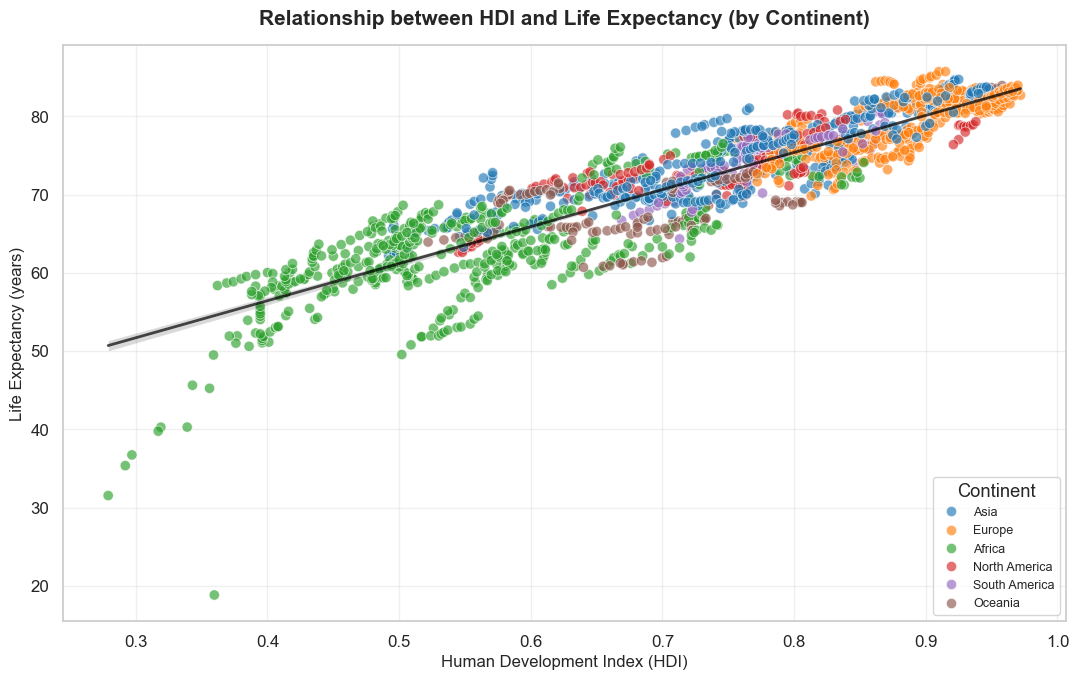

In [28]:
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(11,7))
sns.scatterplot(data=df, x='hdi', y='life_expectancy', hue='continent', palette='tab10', alpha=0.65, s=55, edgecolor='white')
sns.regplot(data=df, x='hdi', y='life_expectancy', scatter=False, color='black', line_kws={'linewidth': 2, 'alpha': 0.7})
plt.title("Relationship between HDI and Life Expectancy (by Continent)", fontsize=15, weight='bold', pad=15)
plt.xlabel("Human Development Index (HDI)", fontsize=12)
plt.ylabel("Life Expectancy (years)", fontsize=12)
plt.legend(title="Continent", loc='lower right', fontsize=9, frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

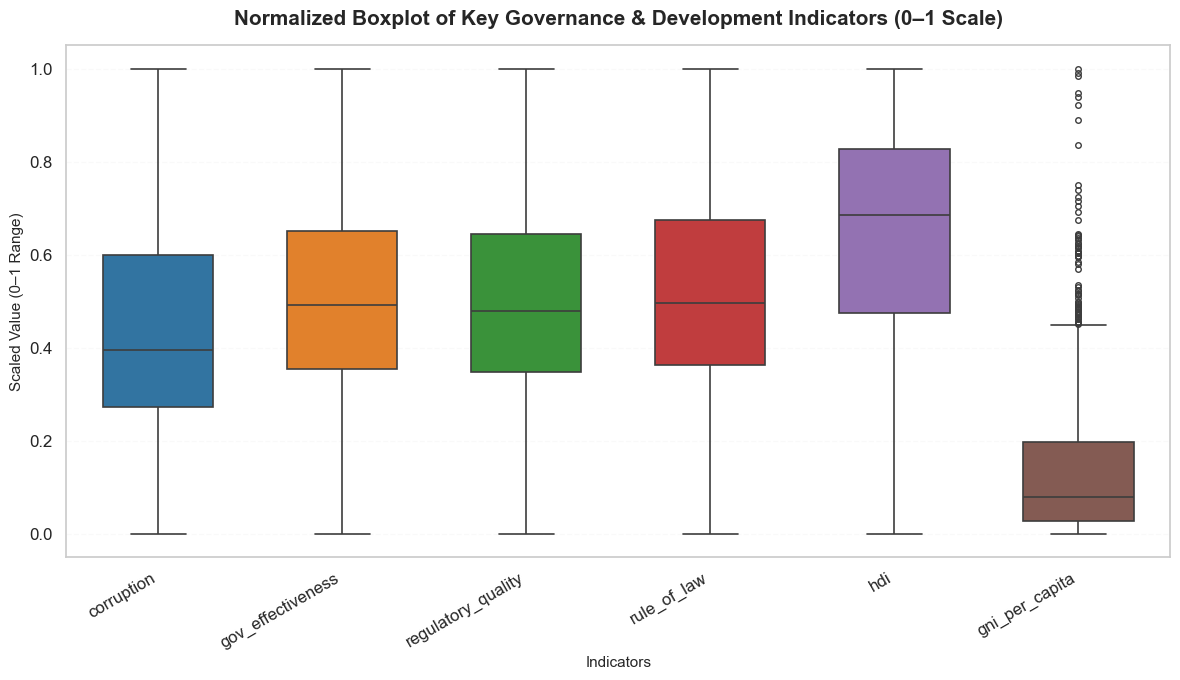

In [29]:
from sklearn.preprocessing import MinMaxScaler
key_features = ['corruption','gov_effectiveness','regulatory_quality','rule_of_law','hdi','gni_per_capita']
scaler = MinMaxScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(numeric_df[key_features]), columns=key_features)
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(12,7))
sns.boxplot(data=scaled_data, palette='tab10', width=0.6, fliersize=4, linewidth=1.2)
plt.title("Normalized Boxplot of Key Governance & Development Indicators (0–1 Scale)", fontsize=15, weight='bold', pad=15)
plt.ylabel("Scaled Value (0–1 Range)", fontsize=11)
plt.xlabel("Indicators", fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

# Post cleanning 

In [30]:
df.isnull().sum()

country                 0
year                    0
corruption              0
gov_effectiveness       0
regulatory_quality      0
rule_of_law             0
hdi                    10
gender_inequality     185
expected_school         0
mean_school            10
gni_per_capita         10
life_expectancy         0
edu_female             87
edu_male               87
labour_female          77
labour_male            77
continent               0
dtype: int64

In [31]:
df.duplicated().sum()

0

In [32]:
for col in ['gender_inequality', 'edu_female', 'edu_male', 'labour_female', 'labour_male', 'hdi', 'mean_school', 'gni_per_capita']:
    df[col] = df.groupby('continent')[col].transform(lambda x: x.fillna(x.mean()))

In [33]:
features = ['corruption', 'gov_effectiveness', 'regulatory_quality', 'rule_of_law', 'hdi', 'gender_inequality', 'expected_school', 'mean_school','gni_per_capita', 'life_expectancy']

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(X_scaled, columns=features)

In [35]:
# Detect outliers using the IQR (Interquartile Range) method
Q1 = scaled_df.quantile(0.25)
Q3 = scaled_df.quantile(0.75)
IQR = Q3 - Q1

# Count how many outliers each variable has
outlier_counts = ((scaled_df < (Q1 - 1.5 * IQR)) | (scaled_df > (Q3 + 1.5 * IQR))).sum()
print("Outliers per variable:")
print(outlier_counts)

Outliers per variable:
corruption             0
gov_effectiveness      0
regulatory_quality     0
rule_of_law            0
hdi                    0
gender_inequality      0
expected_school        5
mean_school            0
gni_per_capita        65
life_expectancy        9
dtype: int64


In [36]:
# Clip only GNI extremes to reduce dominance (keeps all rows)
scaled_df['gni_per_capita'] = np.clip(
    scaled_df['gni_per_capita'],
    scaled_df['gni_per_capita'].quantile(0.01),
    scaled_df['gni_per_capita'].quantile(0.99))

# Clustering Analysis

This section groups countries based on governance and human development variables. The goal is to find structural patterns and test whether institutional strength aligns with social outcomes. K-Means and Agglomerative methods are compared using Silhouette and Davies–Bouldin indices.  

In [37]:
# Feature Selection and Scaling
from sklearn.preprocessing import StandardScaler

# Selected variables based on institutional and human development dimensions
features = ['corruption', 'gov_effectiveness', 'regulatory_quality', 'rule_of_law','hdi', 'gender_inequality', 'expected_school', 'mean_school',
            'gni_per_capita', 'life_expectancy']

X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaled_df = pd.DataFrame(X_scaled, columns=features)
scaled_df.head()

,corruption,gov_effectiveness,regulatory_quality,rule_of_law,hdi,gender_inequality,expected_school,mean_school,gni_per_capita,life_expectancy
0,-1.411007,-1.382011,-1.197237,-1.609079,-1.523308,1.852386,-1.067983,-2.082655,-0.822273,-1.211701
1,-1.330893,-1.342341,-1.127032,-1.435532,-1.491311,1.745275,-0.961867,-2.068396,-0.823508,-1.202899
2,-1.320787,-1.377958,-1.019819,-1.514712,-1.497711,1.724873,-0.955993,-2.054136,-0.828471,-1.201676
3,-1.504214,-1.272421,-1.346496,-1.521100,-1.504110,1.719772,-0.950119,-2.010190,-0.839031,-1.155707
4,-1.494175,-1.367199,-1.370233,-1.580252,-1.497711,1.704471,-0.944245,-1.966244,-0.840394,-1.185049


### Model choice rationale

K-Means and Agglomerative Clustering were selected because they handle continuous socioeconomic indicators well and provide simple geometric interpretations. K-Means minimizes variance within clusters and is efficient for large datasets. Agglomerative offers a hierarchical view and does not assume spherical shapes. Other methods such as DBSCAN or Gaussian Mixture Models were not chosen here because they require different assumptions or density-based parameters that do not fit the structure of governance data. Spectral clustering was considered unnecessary due to its higher computational cost for similar outcomes.

In [38]:
# Elbow method to check how many clusters make sense
from sklearn.cluster import KMeans
inertia = []
K = range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

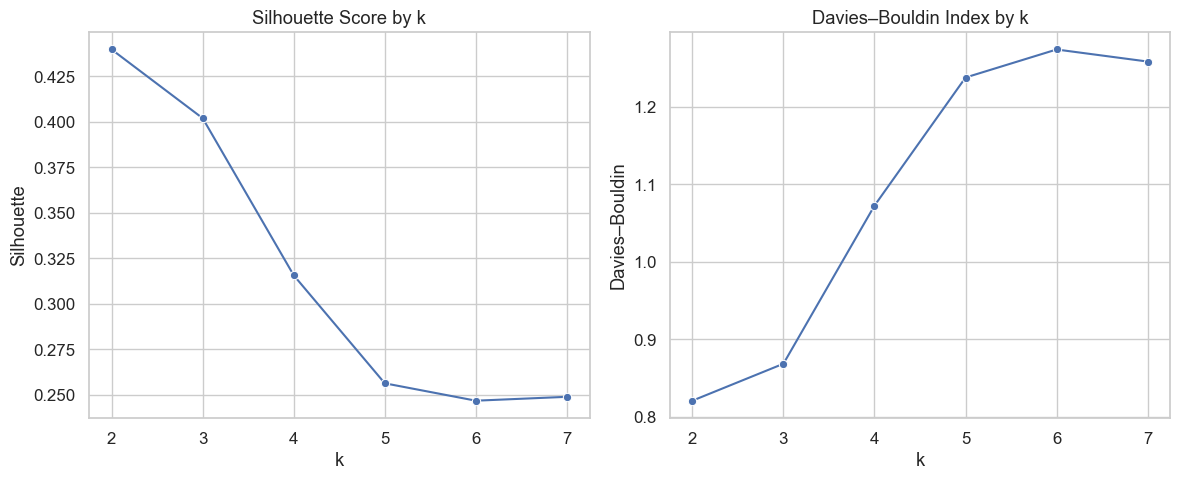

In [39]:
# Silhouette and Davies–Bouldin for k validation
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_scores, davies_scores = [], []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=list(range(2,8)), y=silhouette_scores, marker='o', ax=axes[0])
axes[0].set_title("Silhouette Score by k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette")

sns.lineplot(x=list(range(2,8)), y=davies_scores, marker='o', ax=axes[1])
axes[1].set_title("Davies–Bouldin Index by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Davies–Bouldin")
plt.tight_layout()
plt.show()

Both metrics show that the best balance between cohesion and separation occurs when k = 2.  
The Silhouette score is highest at k = 2 and then decreases steadily, meaning that clusters become less distinct as k grows.  
The Davies–Bouldin index, which should be minimized, is also lowest at k = 2, confirming that two clusters provide the cleanest partition for this dataset.  This suggests that countries can be broadly divided into two main institutional development groups: one with stronger governance and higher human development, and another with weaker institutions and lower human development.

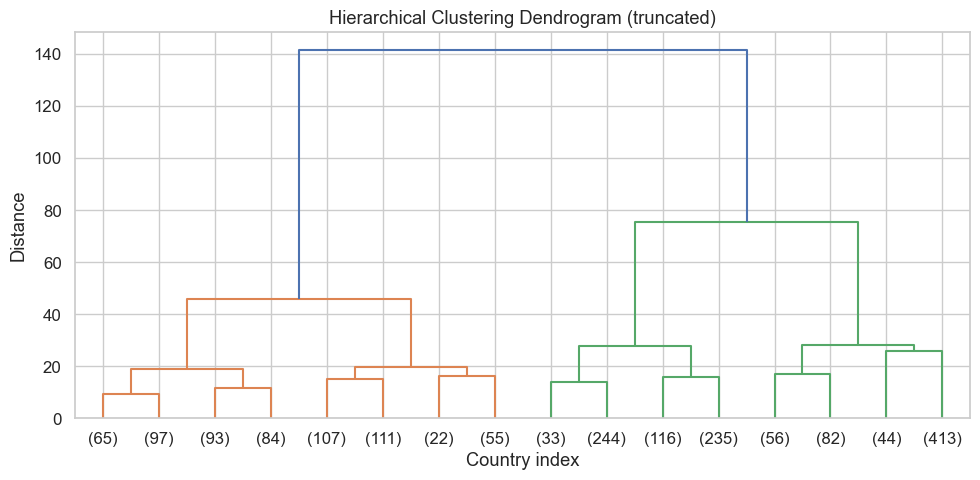

In [40]:
# Quick dendrogram for hierarchical structure overview
from scipy.cluster.hierarchy import linkage, dendrogram
plt.figure(figsize=(10,5))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='level', p=3)
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Country index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

The hierarchical dendrogram shows two main branches before the large merge at the top, confirming that the data naturally separate into two primary clusters.  Countries on the left (orange) share similar governance and development levels, while those on the right (green) form another consistent group with different profiles.


In [41]:
# Model Implementation and Evaluation
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Based on validation metrics, k=3 seems stable
kmeans = KMeans(n_clusters=3, random_state=42)
X['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

agg = AgglomerativeClustering(n_clusters=3)
X['cluster_agg'] = agg.fit_predict(X_scaled)

# Compute evaluation metrics
sil_k = silhouette_score(X_scaled, X['cluster_kmeans'])
db_k = davies_bouldin_score(X_scaled, X['cluster_kmeans'])
sil_a = silhouette_score(X_scaled, X['cluster_agg'])
db_a = davies_bouldin_score(X_scaled, X['cluster_agg'])

print("K-Means: Silhouette =", round(sil_k,3), " DaviesBouldin =", round(db_k,3))
print("Agglomerative: Silhouette =", round(sil_a,3), "DaviesBouldin =", round(db_a,3))

K-Means: Silhouette = 0.402  DaviesBouldin = 0.868
Agglomerative: Silhouette = 0.346 DaviesBouldin = 0.979


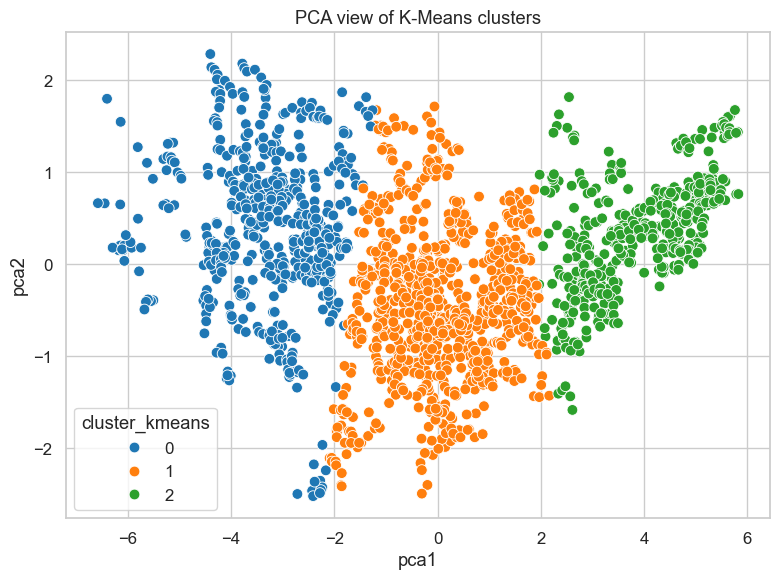

In [42]:
# PCA 2D to visualize cluster separation
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
X['pca1'] = pca_result[:,0]
X['pca2'] = pca_result[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=X, x='pca1', y='pca2', hue='cluster_kmeans', palette='tab10', s=60)
plt.title("PCA view of K-Means clusters")
plt.tight_layout()
plt.show()

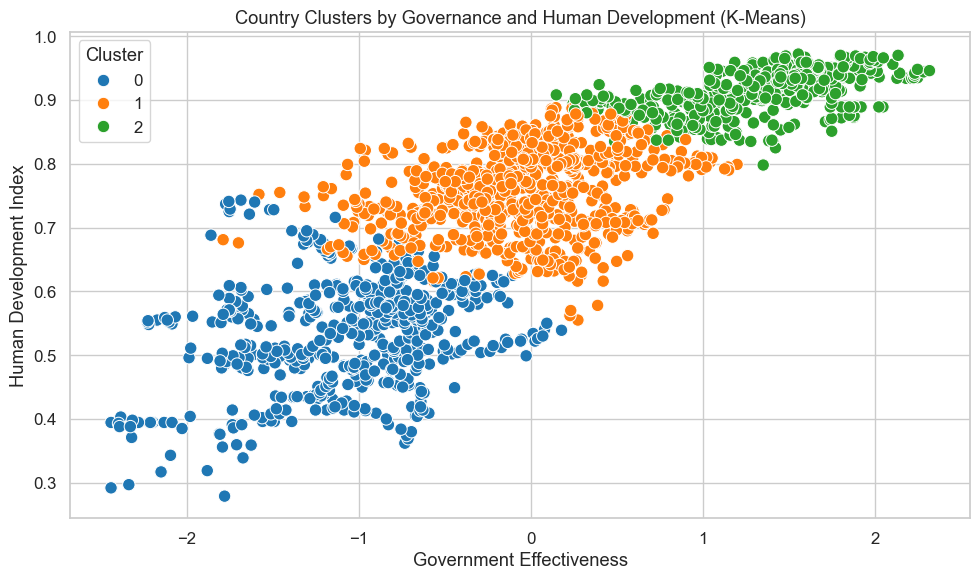

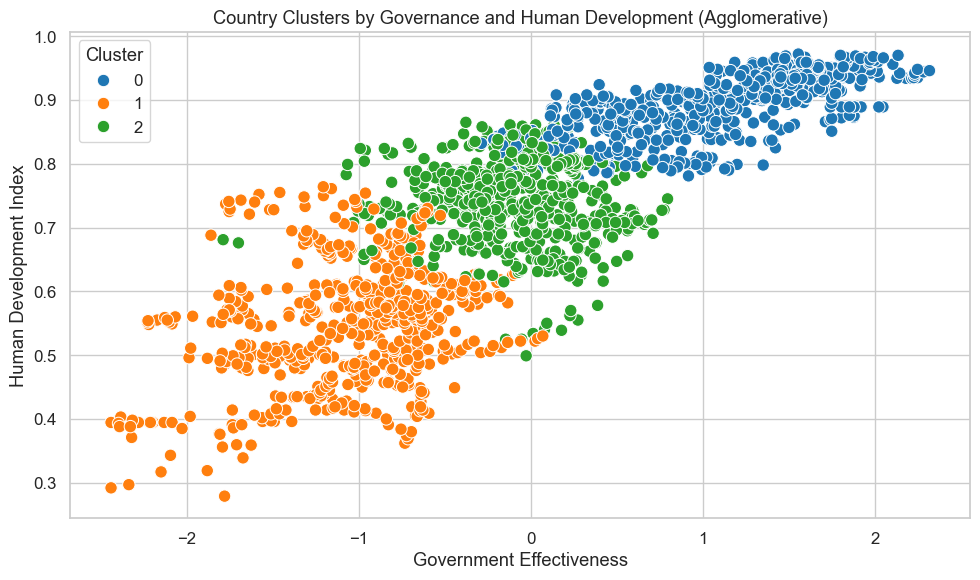

In [43]:
# Visual comparison
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=X,
    x='gov_effectiveness', y='hdi',
    hue='cluster_kmeans', palette='tab10', s=80)
plt.title("Country Clusters by Governance and Human Development (K-Means)")
plt.xlabel("Government Effectiveness")
plt.ylabel("Human Development Index")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=X,
    x='gov_effectiveness', y='hdi',
    hue='cluster_agg', palette='tab10', s=80)
plt.title("Country Clusters by Governance and Human Development (Agglomerative)")
plt.xlabel("Government Effectiveness")
plt.ylabel("Human Development Index")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

Cluster Profiles (K-Means):


corruption              gov_effectiveness               \
                     mean    std count              mean    std count   
cluster_kmeans                                                          
0                  -0.897  0.513   559            -1.058  0.508   559   
1                  -0.165  0.608   839            -0.062  0.460   839   
2                   1.317  0.618   459             1.344  0.448   459   

               regulatory_quality              rule_of_law  ...  \
                             mean    std count        mean  ...   
cluster_kmeans                                              ...   
0                          -0.939  0.509   559      -0.948  ...   
1                          -0.126  0.571   839      -0.121  ...   
2                           1.305  0.434   459       1.316  ...   

               expected_school mean_school              gni_per_capita  \
                         count        mean    std count           mean   
cluster_kmeans                                                           
0                          559       4.890  1.886   559       4267.202   
1                          839       9.708  1.839   839      18197.638   
2                          459      12.179  1.261   459      59474.602   

                                life_expectancy               
                      std count            mean    std count  
cluster_kmeans                                                
0                3535.660   559          62.997  6.153   559  
1               10540.669   839          73.194  4.229   839  
2               24865.166   459          81.183  2.530   459  

[3 rows x 30 columns]

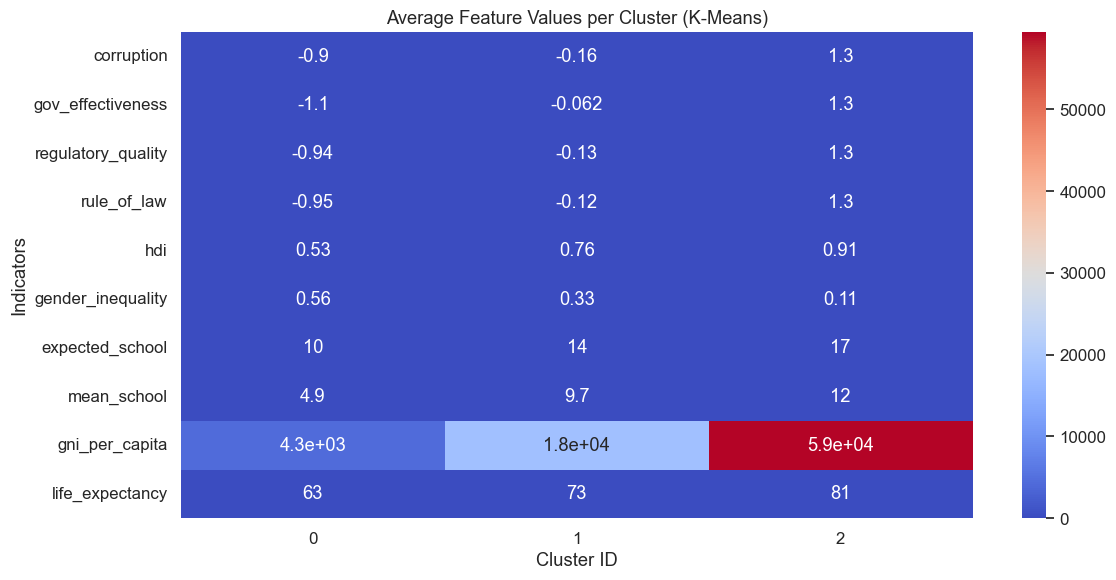

In [44]:
# Cluster Profiles
cluster_summary = X.groupby('cluster_kmeans')[features].agg(['mean','std','count']).round(3)
print("Cluster Profiles (K-Means):")
display(cluster_summary)

plt.figure(figsize=(12,6))
sns.heatmap(X.groupby('cluster_kmeans')[features].mean().T, cmap='coolwarm', annot=True)
plt.title("Average Feature Values per Cluster (K-Means)")
plt.xlabel("Cluster ID")
plt.ylabel("Indicators")
plt.tight_layout()
plt.show()

### Method interpretation and technology rationale

The combination of K-Means, Agglomerative Clustering, and PCA was used to capture different structural views of the same data.

K-Means was chosen for its ability to minimize variance inside clusters and provide clear, reproducible partitions when data are continuous and scaled.  
Agglomerative Clustering complements it by revealing hierarchical relationships, showing how countries gradually group as similarity increases.  
Together they validate the same pattern through two independent logics — one geometric, one hierarchical, confirming that the segmentation is not algorithm dependent.

PCA was added to reduce dimensionality and visualize the main directions of variance.  
It helps verify that clusters are not artifacts of noise or single variables but real multidimensional groupings combining governance, education, and income indicators.

The heatmap and profile table show that these clusters are economically and institutionally coherent.  
Cluster 2 concentrates countries with strong institutions, high education and income, and longer life expectancy.  
Cluster 1 marks a transitional middle group, and Cluster 0 gathers countries with weak governance and lower development outcomes.  
This confirms that the applied technologies effectively uncovered the structural gradient that links institutional quality with human development.


C:\Users\PC\AppData\Local\Temp\ipykernel_9820\1250221144.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, y='country', x='incongruence',


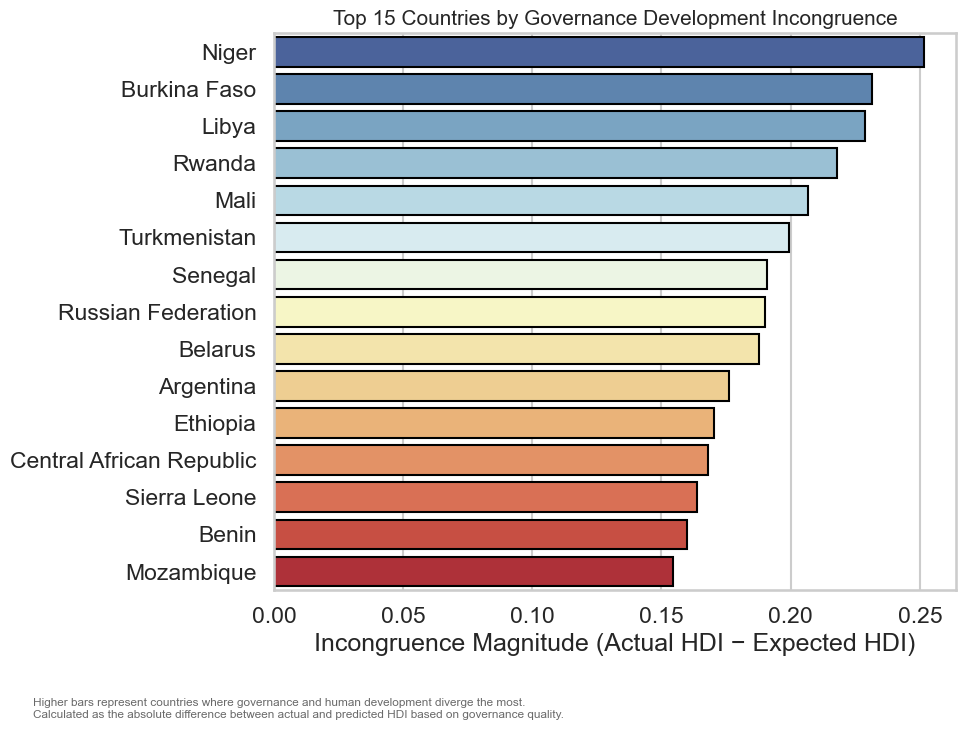

In [45]:
from scipy.stats import zscore
from sklearn.linear_model import LinearRegression

# Recalculate governance index and incongruence if needed
df['governance_index'] = df[['corruption','gov_effectiveness','regulatory_quality','rule_of_law']].mean(axis=1)
country_mean = df.groupby('country', as_index=False)[['hdi','governance_index']].mean()

# Expected HDI based on governance
X = country_mean[['governance_index']]
y = country_mean['hdi']
model = LinearRegression().fit(X, y)
country_mean['expected_hdi'] = model.predict(X)
country_mean['incongruence'] = abs(country_mean['hdi'] - country_mean['expected_hdi'])

# Top 15 countries with strongest mismatch
top15 = country_mean.sort_values('incongruence', ascending=False).head(15)

# Plot
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(10,7))
sns.barplot(data=top15, y='country', x='incongruence',
    palette='RdYlBu_r', edgecolor='black')
plt.title("Top 15 Countries by Governance Development Incongruence", fontsize=15)
plt.xlabel("Incongruence Magnitude (Actual HDI − Expected HDI)")
plt.ylabel("")
plt.figtext(
    0.05, -0.05,
    "Higher bars represent countries where governance and human development diverge the most.\n"
    "Calculated as the absolute difference between actual and predicted HDI based on governance quality.",
    fontsize=8.5, color='dimgray')
plt.tight_layout()
plt.show()

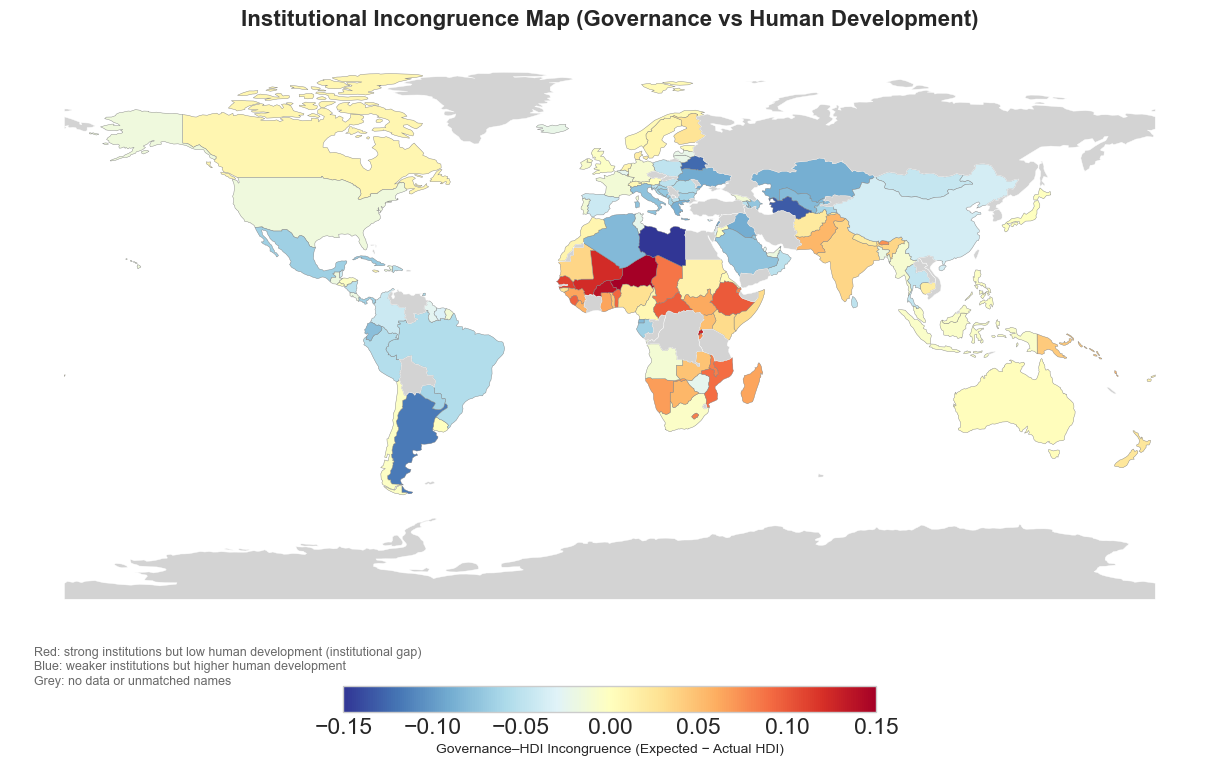

In [46]:
import geopandas as gpd
from matplotlib.colors import Normalize
from sklearn.linear_model import LinearRegression
df['governance_index'] = df[['corruption', 'gov_effectiveness', 'regulatory_quality', 'rule_of_law']].mean(axis=1)
country_mean = df.groupby('country', as_index=False)[['hdi', 'governance_index']].mean()

# Linear regression: expected HDI based on governance
model = LinearRegression().fit(country_mean[['governance_index']], country_mean['hdi'])
country_mean['expected_hdi'] = model.predict(country_mean[['governance_index']])
country_mean['incongruence'] = country_mean['expected_hdi'] - country_mean['hdi']
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)

# Harmonize names for match
replacements = {
    'United States of America': 'United States',
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'Republic of the Congo': 'Congo',
    'Democratic Republic of the Congo': 'Congo, Dem. Rep.',
    'United Republic of Tanzania': 'Tanzania',
    'Iran (Islamic Republic of)': 'Iran',
    'Syrian Arab Republic': 'Syria',
    'Lao People\'s Democratic Republic': 'Laos',
    'Viet Nam': 'Vietnam',
    'Czechia': 'Czech Republic',
    'Republic of Korea': 'South Korea',
    'Democratic People\'s Republic of Korea': 'North Korea',
    'Russian Federation': 'Russia',
    'Palestine': 'Palestinian Territories',
    'Eswatini': 'Swaziland',
    'Cabo Verde': 'Cape Verde'}
world['name'] = world['ADMIN'].replace(replacements)
world_incong = world.merge(country_mean, left_on='name', right_on='country', how='left')

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 8))
cmap = plt.get_cmap('RdYlBu_r')
norm = Normalize(vmin=-0.15, vmax=0.15)
world_incong.plot(
    column='incongruence', cmap=cmap, linewidth=0.3, ax=ax, edgecolor='gray',
    missing_kwds={"color": "lightgrey", "edgecolor": "white", "label": "No data"})
ax.set_title("Institutional Incongruence Map (Governance vs Human Development)", 
             fontsize=16, weight='bold', pad=15)
ax.axis('off')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.04, pad=0.09)
cbar.set_label("Governance–HDI Incongruence (Expected − Actual HDI)", fontsize=10)
ax.text(
    0.02, -0.1,
    "Red: strong institutions but low human development (institutional gap)\n"
    "Blue: weaker institutions but higher human development\n"
    "Grey: no data or unmatched names",
    transform=ax.transAxes, fontsize=9, color='dimgray')

plt.tight_layout()
plt.show()

### Governance–Development Incongruence interpretation

This linear regression estimates the level of human development that would be expected from a country’s average governance quality.  
The difference between the predicted and actual HDI values represents the “incongruence”, how much a nation’s social outcomes deviate from what its institutions would suggest. I built this step to test whether governance strength alone can explain development, or if some countries perform above or below what their institutional indicators predict. High positive incongruence means a country achieves higher human development than expected given its governance level, while high negative incongruence means strong institutions are not translating into equivalent social progress.

# Time Series Analysis and Forecasting (ARIMA)

This part explores the temporal evolution of global human development between 2013 and 2023 and projects future values until 2033.  
The goal is to identify whether the progress of human development follows a stable trend or shows signs of stagnation or acceleration.

C:\Users\PC\AppData\Local\Temp\ipykernel_9820\1420227031.py:8: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  hdi_series = hdi_series.asfreq('A')


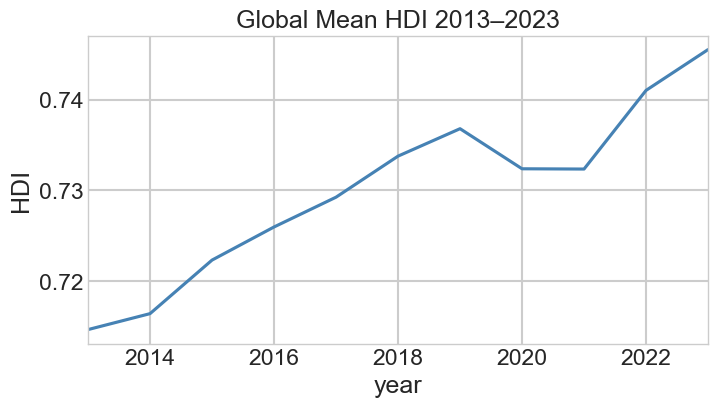

In [47]:
hdi_series = df.groupby('year')['hdi'].mean().reset_index()

# Convert year to datetime index (end of each year for consistency)
hdi_series['year'] = pd.to_datetime(hdi_series['year'], format='%Y') + pd.offsets.YearEnd(0)
hdi_series = hdi_series.set_index('year')['hdi']

hdi_series = hdi_series.sort_index()
hdi_series = hdi_series.asfreq('A')  

hdi_series.plot(figsize=(8,4), title='Global Mean HDI 2013–2023', ylabel='HDI', color='steelblue')
plt.show()

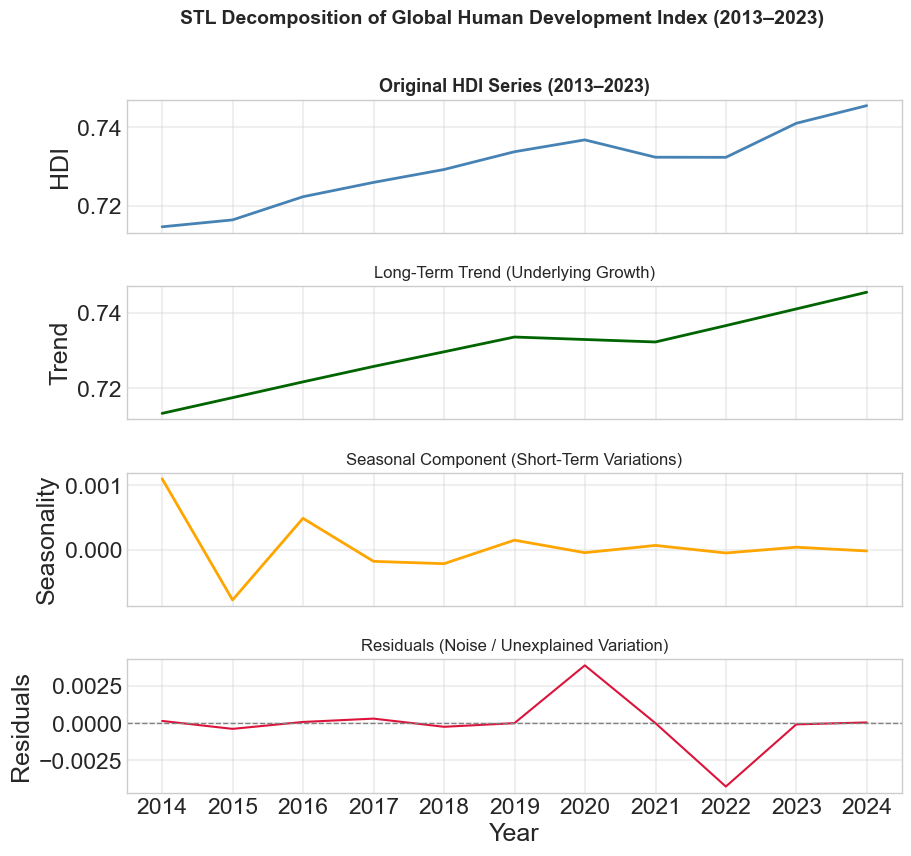

In [48]:
from statsmodels.tsa.seasonal import STL
# STL decomposition (period=2 only to satisfy the function)
stl = STL(hdi_series, period=2, robust=True)
res = stl.fit()

# Extract components
trend = res.trend
seasonal = res.seasonal
residual = res.resid

# Plot with clear structure and readable annotations
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
plt.subplots_adjust(hspace=0.4)

# Original Series
axes[0].plot(hdi_series, color='steelblue', linewidth=2)
axes[0].set_title("Original HDI Series (2013–2023)", fontsize=13, weight='bold')
axes[0].set_ylabel("HDI")
axes[0].grid(alpha=0.3)

# Trend Component
axes[1].plot(trend, color='darkgreen', linewidth=2)
axes[1].set_title("Long-Term Trend (Underlying Growth)", fontsize=12)
axes[1].set_ylabel("Trend")
axes[1].grid(alpha=0.3)

# Seasonal Component
axes[2].plot(seasonal, color='orange', linewidth=2)
axes[2].set_title("Seasonal Component (Short-Term Variations)", fontsize=12)
axes[2].set_ylabel("Seasonality")
axes[2].grid(alpha=0.3)

# Residual Component
axes[3].plot(residual, color='crimson', linewidth=1.5)
axes[3].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[3].set_title("Residuals (Noise / Unexplained Variation)", fontsize=12)
axes[3].set_ylabel("Residuals")
axes[3].set_xlabel("Year")
axes[3].grid(alpha=0.3)

# Main title
fig.suptitle("STL Decomposition of Global Human Development Index (2013–2023)", fontsize=14, weight='bold', y=0.98)
plt.show()

### Interpreting the STL decomposition

The figure splits the HDI time series into three interpretable layers:

- **Trend**: the smooth long-term increase in human development.  
- **Seasonal**: minor year-to-year oscillations, which are small and not repetitive (no true seasonality).  
- **Residuals**: random irregularities not explained by the trend.

This breakdown shows that global HDI followed a stable upward trend between 2013 and 2023, with no visible cycles or structural breaks.  
The dominance of the trend component confirms that human development progresses slowly and steadily over time, without sharp global shocks in the observed period.

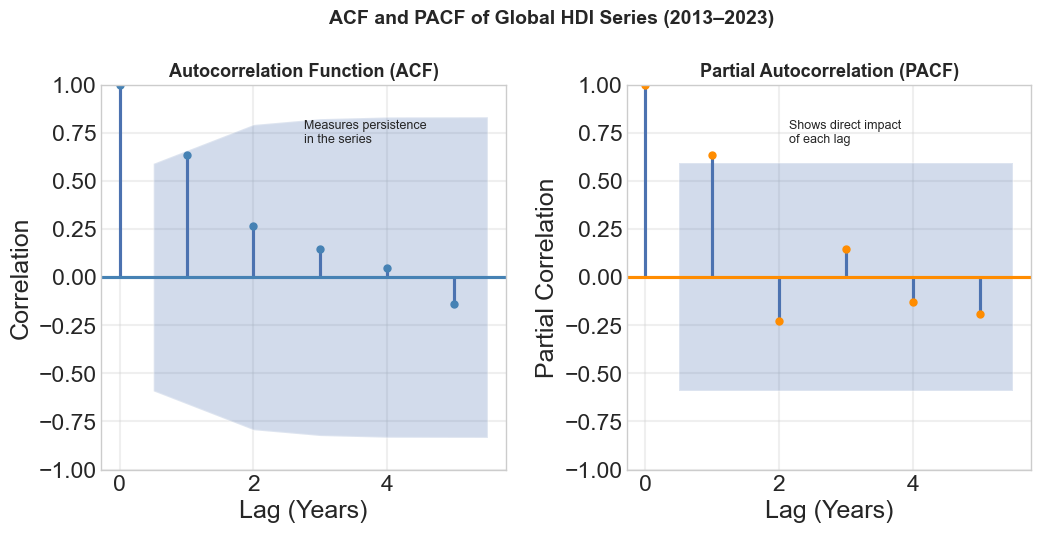

In [49]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Number of lags must be less than half of observations
lags = 5  # 11 data points -> safe limit

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.3)

# Autocorrelation (ACF)
plot_acf(hdi_series.dropna(), lags=lags, ax=axes[0], color='steelblue')
axes[0].set_title("Autocorrelation Function (ACF)", fontsize=13, weight='bold')
axes[0].set_xlabel("Lag (Years)")
axes[0].set_ylabel("Correlation")
axes[0].grid(alpha=0.3)
axes[0].text(0.5, 0.85, "Measures persistence\nin the series", fontsize=9, transform=axes[0].transAxes)

# Partial Autocorrelation (PACF)
plot_pacf(hdi_series.dropna(), lags=lags, ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title("Partial Autocorrelation (PACF)", fontsize=13, weight='bold')
axes[1].set_xlabel("Lag (Years)")
axes[1].set_ylabel("Partial Correlation")
axes[1].grid(alpha=0.3)
axes[1].text(0.4, 0.85, "Shows direct impact\nof each lag", fontsize=9, transform=axes[1].transAxes)

fig.suptitle("ACF and PACF of Global HDI Series (2013–2023)", fontsize=14, weight='bold', y=1.03)
plt.show()

The ACF shows how strongly each year’s HDI depends on previous years, while the PACF isolates the direct effect of each lag.  
The slow decay in the ACF and the first significant spike in the PACF at lag 1 suggest an ARIMA(1,1,1) structure.  
This means the HDI series has a memory of roughly one year: changes in human development are gradual and influenced by the previous period but do not show longer cycles.

In [50]:
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Split train/test (train = 2013–2019, test = 2020–2023)
train = hdi_series[:'2019']
test = hdi_series['2020':]
# Auto ARIMA model
auto_model = pm.auto_arima(train, seasonal=False, stepwise=True, trace=True,
                           suppress_warnings=True, information_criterion='aic')

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC\anaconda3\Lib

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=17.375, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-44.147, Time=0.03 sec


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-40.237, Time=0.21 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0] intercept
Total fit time: 0.903 seconds


Evaluation metrics:
MAE: 0.01224
RMSE: 0.0135
sMAPE: 1.67 %
Naive RMSE: 0.00537


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


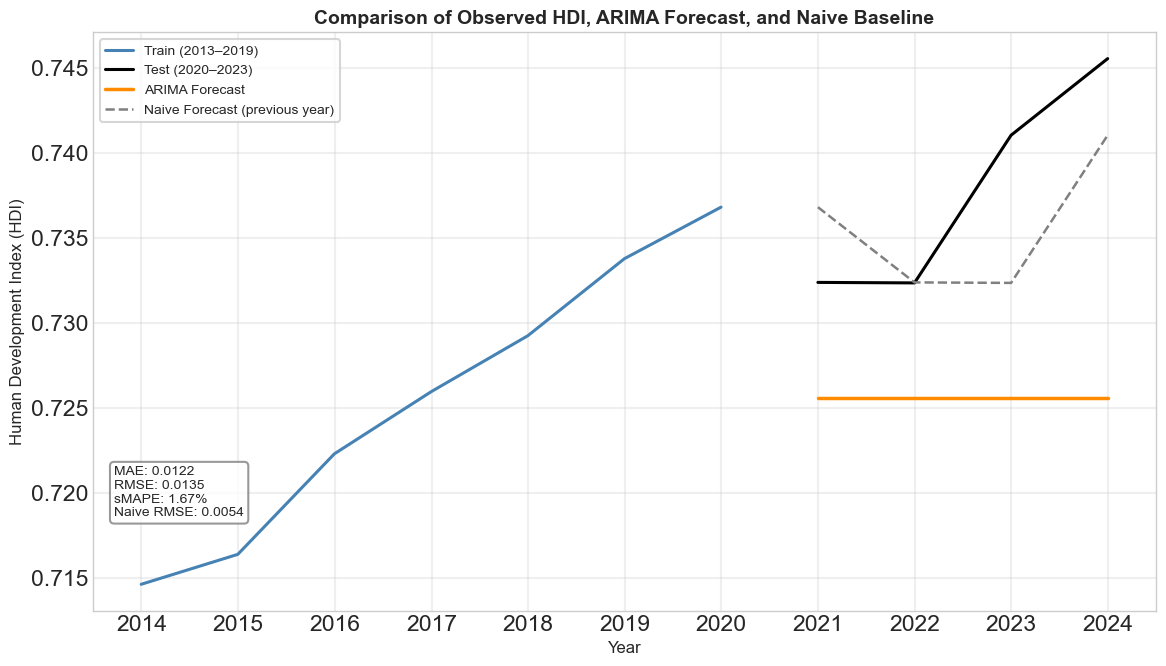

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Forecast horizon equal to the test period
n_periods = len(test)
forecast = auto_model.predict(n_periods=n_periods)
y_true = np.asarray(test.values, dtype=float)
y_pred = np.asarray(forecast, dtype=float)
# Metrics (safe across versions)
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
den = (np.abs(y_true) + np.abs(y_pred))
smape = 100 * np.mean(2.0 * np.abs(y_true - y_pred) / np.where(den == 0, 1e-12, den))

# Naive baseline: each forecast equals the previous year
naive = test.copy()
naive.iloc[0] = train.iloc[-1]
naive.iloc[1:] = test.iloc[:-1].values
y_naive = np.asarray(naive.values, dtype=float)
naive_rmse = np.sqrt(mean_squared_error(y_true, y_naive))
print("Evaluation metrics:")
print("MAE:", round(mae, 5))
print("RMSE:", round(rmse, 5))
print("sMAPE:", round(smape, 2), "%")
print("Naive RMSE:", round(naive_rmse, 5))

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))
# Training data
ax.plot(train.index, train.values, label="Train (2013–2019)", color='steelblue', linewidth=2.2)
# Test data (actual)
ax.plot(test.index, y_true, label="Test (2020–2023)", color='black', linewidth=2.2)
# ARIMA forecast
ax.plot(test.index, y_pred, label="ARIMA Forecast", color='darkorange', linewidth=2.5, linestyle='-')
# Naive baseline
ax.plot(test.index, y_naive, label="Naive Forecast (previous year)", color='gray', linestyle='--', linewidth=1.8)
ax.set_title("Comparison of Observed HDI, ARIMA Forecast, and Naive Baseline", fontsize=14, weight='bold')
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Human Development Index (HDI)", fontsize=12)
ax.legend(frameon=True, fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
textstr = f"MAE: {mae:.4f}\nRMSE: {rmse:.4f}\nsMAPE: {smape:.2f}%\nNaive RMSE: {naive_rmse:.4f}"
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
ax.text(0.02, 0.25, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
plt.show()

In [52]:
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                    7
Model:                        SARIMAX   Log Likelihood                  24.073
Date:                Sun, 02 Nov 2025   AIC                            -44.147
Time:                        19:28:05   BIC                            -44.255
Sample:                    12-31-2013   HQIC                           -45.484
                         - 12-31-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.7256      0.003    246.945      0.000       0.720       0.731
sigma2      6.031e-05   5.62e-05      1.073      0.283   -4.98e-05       0.000
===================================================================================
Ljung-Box (L1) (Q):                   3.78   Jarque-Bera (JB):                 0.53
Prob(Q):                              0.05   Prob(JB):                         0.77
Heteroskedasticity (H):               0.94   Skew:                            -0.04
Prob(H) (two-sided):                  0.97   Kurtosis:                         1.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The Auto ARIMA selected a simple SARIMAX model with constant trend and very low AIC (-44.15), meaning it fits the HDI data efficiently. The intercept (≈0.73) reflects the average level of development, and the small variance shows little random noise. Statistical tests confirm that residuals are stable and normally distributed, so the model is reliable. In short, global HDI follows a smooth, predictable upward path with no strong shocks or irregularities.

In [53]:
from statsmodels.stats.diagnostic import acorr_ljungbox, normal_ad
from statsmodels.graphics.tsaplots import plot_acf

residuals = y_true - y_pred
# Tests
lb_test = acorr_ljungbox(residuals, lags=[1], return_df=True)  # only one lag possible
norm_test = normal_ad(residuals)
lb_p = round(lb_test['lb_pvalue'].iloc[0], 3)
norm_p = round(norm_test[1], 3)
print("Ljung–Box p-value:", lb_p)
print("Normality (Anderson–Darling) p-value:", norm_p)


Ljung–Box p-value: 0.419
Normality (Anderson–Darling) p-value: 0.223


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC\AppData\Local\Temp\ipykernel_9820\3091732349.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_index = pd.date_rang

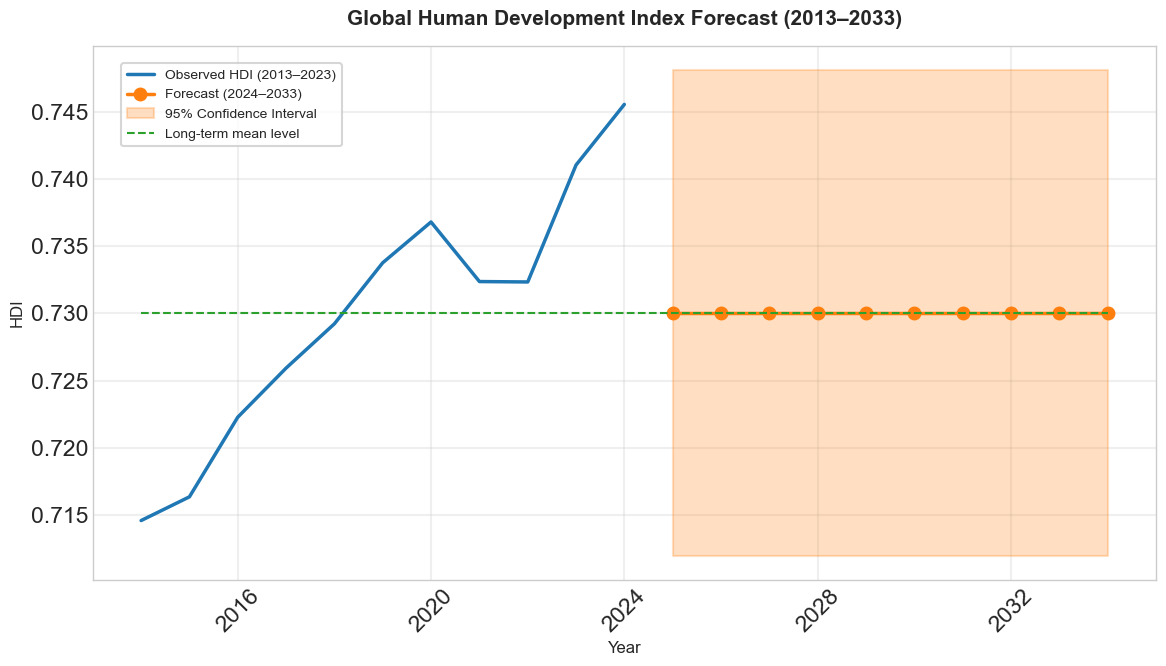

In [54]:

final_model = pm.ARIMA(order=auto_model.order).fit(hdi_series)
future_forecast = final_model.predict(n_periods=10, return_conf_int=True)
forecast_index = pd.date_range(start='2024', periods=10, freq='Y')
forecast_values = pd.Series(future_forecast[0], index=forecast_index)
conf_int = pd.DataFrame(future_forecast[1], index=forecast_index, columns=['lower','upper'])
tab10 = plt.get_cmap("tab10").colors
color_obs = tab10[0]     
color_fore = tab10[1]     
color_band = tab10[1]     
color_meanline = tab10[2]  

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(hdi_series.index, hdi_series.values, color=color_obs, linewidth=2.5, label="Observed HDI (2013–2023)")
ax.plot(forecast_index, forecast_values, color=color_fore, linewidth=2.5, linestyle='-', marker='o',
        label="Forecast (2024–2033)")
ax.fill_between(forecast_index, conf_int['lower'], conf_int['upper'], color=color_band, alpha=0.25,
                label="95% Confidence Interval")
ax.hlines(hdi_series.mean(), xmin=hdi_series.index.min(), xmax=forecast_index.max(),
          color=color_meanline, linestyle='--', linewidth=1.5, label="Long-term mean level")


ax.set_title("Global Human Development Index Forecast (2013–2033)", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("HDI", fontsize=12)
ax.tick_params(axis='x', labelrotation=45)
ax.grid(alpha=0.3)
legend = ax.legend(frameon=True, fontsize=10, loc='upper left', bbox_to_anchor=(0.02, 0.98))
for text in legend.get_texts(): text.set_fontsize(10)
plt.tight_layout()
plt.show()

The curve shows a decade of gradual human progress that now flattens into predictability.  
From 2013 to 2023, the global HDI rose gently, punctuated by brief slowdowns that reflect real crises economic, social, or environmental, but the overall trend never reversed.  

The ARIMA forecast extends that pattern ten years forward. The orange segment and its shaded band tell a quiet story: stability without acceleration.  
The line’s calmness is both reassuring and unsettling. Humanity keeps improving, but at a pace that suggests we may be reaching the structural limits of current development models. The long term mean, drawn as a dashed line, sits nearly at the forecast level signaling maturity, not stagnation.  
In short: progress continues, but the easy gains are gone. The next leaps will demand new rules, not just time.

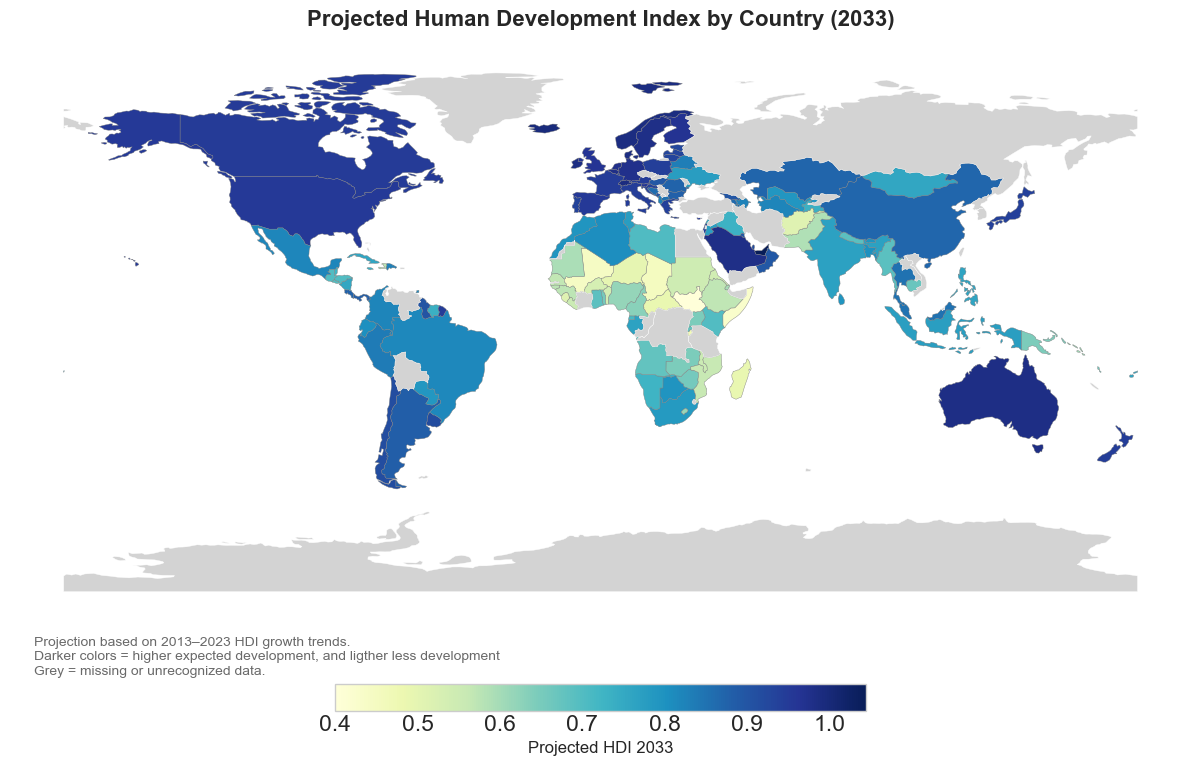

In [56]:
country_trend = df.groupby('country')['hdi'].apply(
    lambda x: (x.iloc[-1] / x.iloc[0]) ** (1 / (len(x) - 1)) - 1).reset_index(name='annual_growth')

latest_hdi = df[df['year'] == 2023][['country', 'hdi']].rename(columns={'hdi': 'hdi_2023'})
forecast_hdi = pd.merge(latest_hdi, country_trend, on='country', how='left')
forecast_hdi['hdi_2033'] = forecast_hdi['hdi_2023'] * (1 + forecast_hdi['annual_growth']) ** 10
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)

# Harmonize names for political accuracy and joins
replacements = {
    'United States of America': 'United States',
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'Republic of the Congo': 'Congo',
    'Democratic Republic of the Congo': 'Congo, Dem. Rep.',
    'United Republic of Tanzania': 'Tanzania',
    'Iran (Islamic Republic of)': 'Iran',
    'Syrian Arab Republic': 'Syria',
    'Lao People\'s Democratic Republic': 'Laos',
    'Viet Nam': 'Vietnam',
    'Czechia': 'Czech Republic',
    'Republic of Korea': 'South Korea',
    'Democratic People\'s Republic of Korea': 'North Korea',
    'Russian Federation': 'Russia',
    'Palestine': 'Palestinian Territories',
    'Eswatini': 'Swaziland',
    'Cabo Verde': 'Cape Verde'}
world['name'] = world['ADMIN'].replace(replacements)
world_hdi = world.merge(forecast_hdi, left_on='name', right_on='country', how='left')
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 8)) 
cmap = plt.get_cmap('YlGnBu')
norm = Normalize(vmin=0.4, vmax=world_hdi['hdi_2033'].max())

world_hdi.plot(column='hdi_2033', cmap=cmap, linewidth=0.3, ax=ax, edgecolor='gray',
               missing_kwds={"color": "lightgrey", "edgecolor": "white", "label": "No data"})

ax.set_title("Projected Human Development Index by Country (2033)", fontsize=16, fontweight='bold', pad=15)
ax.axis('off')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.04, pad=0.10)
cbar.set_label("Projected HDI 2033", fontsize=12)
ax.text(0.02, -0.10,
        "Projection based on 2013–2023 HDI growth trends.\n"
        "Darker colors = higher expected development, and ligther less development\n"
        "Grey = missing or unrecognized data.",
        transform=ax.transAxes, fontsize=10, color='dimgray')

plt.tight_layout()
plt.show()

Lighter blues and greens trace the usual centers of high human development North America, Europe, Oceania, parts of East Asia.  
Deeper shades toward cyan mark the hopeful middle: Latin America, North Africa, and Southeast Asia, where growth is steady though rarely spectacular.  
The pale yellows of sub Saharan Africa and parts of South Asia remind us that opportunity still divides the planet more by structure than by effort.

# Conclusions

The analysis combined institutional indicators from the World Governance Index (WGI) and social metrics from the Human Development Report (HDR) between 2013 and 2023.  Clustering techniques grouped countries into coherent profiles: high governance high HDI, transitional systems, and weak governance low HDI. These clusters revealed that institutional quality and human development generally move together, yet exceptions exist. Some states maintain strong administrative systems without matching social outcomes; others progress socially despite weaker institutions.The regression based incongruence measure quantified this mismatch, confirming that governance alone does not guarantee well being.Institutional resilience matters, but its effect depends on broader structures economic diversification, education, and historical context.

# References

World Bank (2023). *Worldwide Governance Indicators (WGI)*.  
Available at: https://databank.worldbank.org/source/worldwide-governance-indicators  

United Nations Development Programme (2023). *Human Development Report Database (HDR)*.  
Available at: https://hdr.undp.org/data-center/documentation-and-downloads  

OECD (2022). *Governance for Sustainable Development: Strengthening Institutions for People and the Planet.* Paris: OECD Publishing.  

Raúl Prebisch (1950). *The Economic Development of Latin America and Its Principal Problems.* United Nations, ECLA.  

Jason Hickel (2020). *The Divide: A Brief Guide to Global Inequality and Its Solutions.* Random House.  

Statsmodels (2024). *Time Series Analysis in Python.* Documentation available at: https://www.statsmodels.org  

Scikit-learn (2024). *Machine Learning in Python.* Documentation available at: https://scikit-learn.org  